# Python e API

### O que é uma API?

- É um conjunto de códigos para usar um serviço/site/aplicativo específico. Cada site/ferramenta tem sua própria API. É importante que você saiba ler as APIs que precisar para saber usar

- Um dos padrões mais comuns em API é pegar informações em formato json, uma espécie de dicionário que precisa ser tratada no Python para podermos analisar

- As possibilidades de API são infinitas, vamos fazer 2 exemplos aqui: Cotação de Moedas e Envio de SMS.

- Sites como Google, Youtube, Facebook, Twitter, ArcGis e praticamente qualquer ferramenta/site grande tem uma API.

### O que precisamos:

- Quase sempre você precisa de uma conta para consumir uma API. Algumas APIs são abertas, como a https://docs.awesomeapi.com.br/api-de-moedas , mas em muitos casos (como veremos no caso do SMS) vamos precisar ter uma conta ativa para consumir a API

- A Documentação da API (ou exemplos da internet) é a chave para conseguir usar uma API 

In [ ]:
import requests
import json

cotacoes = requests.get('https://economia.awesomeapi.com.br/json/all')

cotacoes_dir = cotacoes.json()

print(cotacoes)
print(cotacoes_dir)



<Response [200]>
{'USD': {'code': 'USD', 'codein': 'BRL', 'name': 'Dólar Americano/Real Brasileiro', 'high': '5.352', 'low': '5.34144', 'varBid': '0.002', 'pctChange': '0.037404', 'bid': '5.3495', 'ask': '5.3525', 'timestamp': '1759108225', 'create_date': '2025-09-28 22:10:25'}, 'USDT': {'code': 'USD', 'codein': 'BRLT', 'name': 'Dólar Americano/Real Brasileiro Turismo', 'high': '5.39031', 'low': '5.37967', 'varBid': '0.00201', 'pctChange': '0.037323', 'bid': '5.38779', 'ask': '5.55444', 'timestamp': '1759108225', 'create_date': '2025-09-28 22:10:25'}, 'CAD': {'code': 'CAD', 'codein': 'BRL', 'name': 'Dólar Canadense/Real Brasileiro', 'high': '3.83835', 'low': '3.83371', 'varBid': '0.00092', 'pctChange': '0.023985', 'bid': '3.83631', 'ask': '3.84594', 'timestamp': '1759108222', 'create_date': '2025-09-28 22:10:22'}, 'GBP': {'code': 'GBP', 'codein': 'BRL', 'name': 'Libra Esterlina/Real Brasileiro', 'high': '7.18177', 'low': '7.16332', 'varBid': '0.006824', 'pctChange': '0.095166', 'bid': 

5.80883


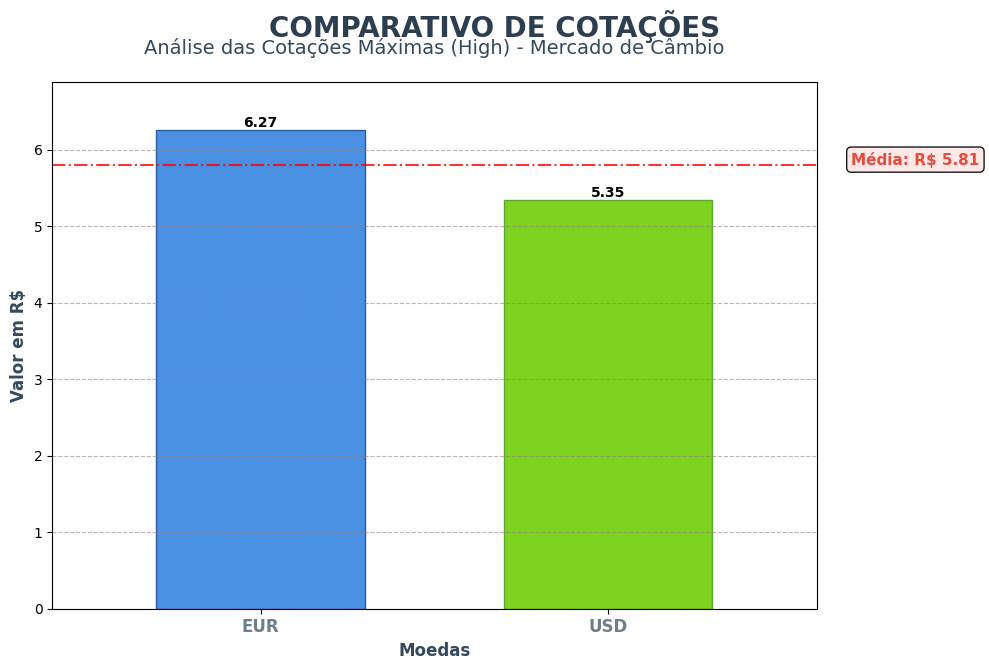

In [131]:
import matplotlib.pyplot as plt
import pandas as pd


df = pd.DataFrame(cotacoes_dir).T

colunas_numericas = [ 'high', 'low', 'bid', 'ask']
for coluna in colunas_numericas:
    df[coluna] = df[coluna].astype(float)

moedas = [ 'EUR', 'USD']
valores = [df.loc[m, 'high'] for m in moedas]
media = sum(valores) / len(moedas)
print(media)

# Criação da figura e eixos
plt.subplots(figsize=(10, 7))

cores = ['#4a90e2', '#7ed321']  # Azul moderno e verde vibrante
cores_escuras = ['#2c5aa0', '#5ba832']  # Versões mais escuras para bordas


# Barras com cores personalizadas
bars = plt.bar(moedas, valores, color=cores, edgecolor=cores_escuras, width=0.6)

# Adiciona rótulos automáticos (com 2 casas decimais)
plt.bar_label(bars, fmt='%.2f', fontsize=10, weight='bold')




plt.axhline(y=media, color='red', linestyle='-.', alpha=0.8)
plt.text(len(valores) - 0.3,  (media) ,  f'Média: R$ {media:.2f}', 
         fontsize=11, 
         color='#e74c3c',           
         fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='#ffe6e6', alpha=0.9)
        )


# Título e rótulos dos eixos
plt.suptitle('COMPARATIVO DE COTAÇÕES', fontsize=20, fontweight='bold', 
             color='#2c3e50', y=0.95)

plt.title('Análise das Cotações Máximas (High) - Mercado de Câmbio', 
          fontsize=14, color='#34495e', pad=20)

plt.ylabel('Valor em R$', fontsize=12, color='#34495e', fontweight='bold')
plt.xlabel('Moedas', fontsize=12, color='#34495e', fontweight='bold')

plt.xticks(fontsize=12, color="#34495eb5", fontweight='bold')
# Grade horizontal suave para facilitar leitura
plt.grid(axis='y', linestyle='--', alpha=0.6, color = "#948282")

plt.ylim(0, max(valores) * 1.1)
margin = 0.1
plt.xlim(-0.5 - margin, len(moedas) - 0.5 + margin)

plt.tight_layout()
plt.show()
